In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df_cities=pd.read_csv("main_cities.csv")
df_cities=df_cities.drop(columns="Unnamed: 0")

In [15]:
def _compute_distance(city_1, city_2):
    delta_long = city_1["longitude"] - city_2["longitude"]
    delta_lat = city_1["latitude"] - city_2["latitude"]
    dist = np.sqrt(delta_long**2 + delta_lat**2)
    return dist

df_cities["distances"] = df_cities.apply(
    lambda city: df_cities.apply(lambda other: _compute_distance(city, other), axis=1).to_list(),
    axis=1
) 

df_cities

,latitude,longitude,population_est,distances
0,31.529,35.094,706508,"[0.0, 0.2669868910639628, 0.7102562917707905, ..."
1,31.768,35.213,419108,"[0.2669868910639628, 0.0, 0.4548516241589074, ..."
2,32.221,35.254,380961,"[0.7102562917707905, 0.4548516241589074, 0.0, ..."
3,31.900,35.204,348110,"[0.38696382259844253, 0.1323064624271976, 0.32..."
4,32.459,35.300,311231,"[0.9525418625971273, 0.6964553108419828, 0.242..."
5,31.705,35.203,216114,"[0.2070193227696386, 0.06378871373527029, 0.51..."
6,32.312,35.027,182053,"[0.7858613109194246, 0.5749191247471218, 0.244..."
7,32.190,34.971,110800,"[0.6723466367878985, 0.48646479831535566, 0.28..."
8,32.083,35.180,70727,"[0.5606353538620251, 0.31672385448525764, 0.15..."
9,32.322,35.369,64719,"[0.839329494298874, 0.575544959147417, 0.15305..."


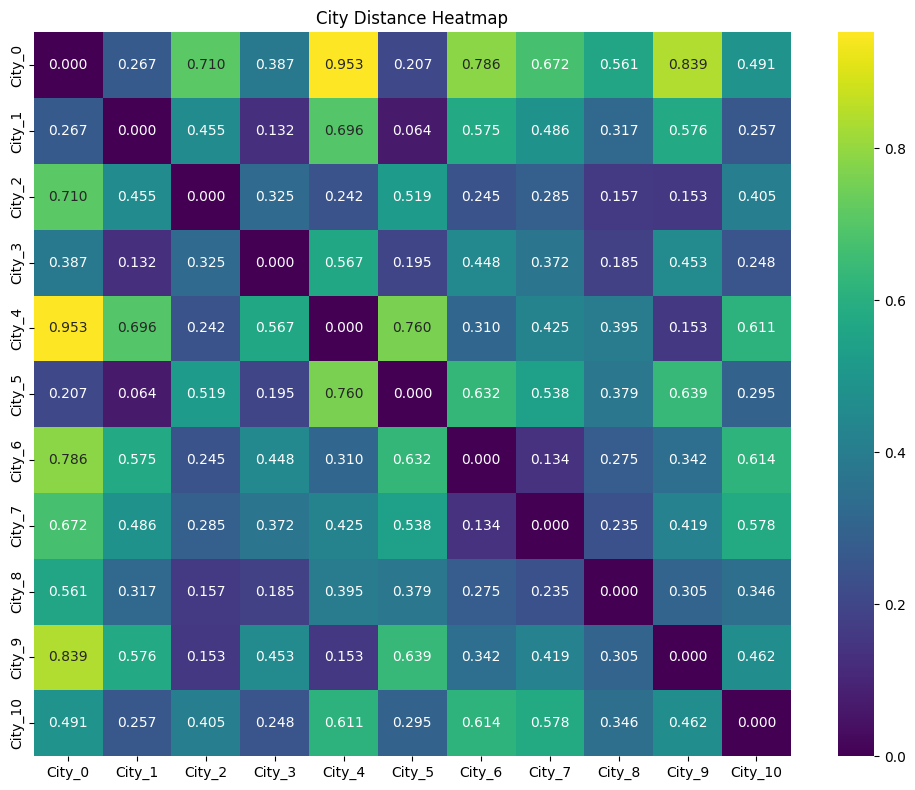

In [ ]:
city_labels = [f"City_{i}" for i in df_cities.index]

distance_table = pd.DataFrame(df_cities["distances"].to_list(),index=city_labels,columns=city_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(distance_table,cmap="viridis",annot=True,fmt=".3f",cbar=False)
plt.show()